## Task 1 – Dataset Understanding

In [3]:
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load dataset
df = pd.read_csv("customer_churn_nn.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn dtypes:")
print(df.dtypes)


Shape: 2000 rows × 17 columns

Column dtypes:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [2]:
# ── Upload your CSV file ──────────────────────────────────────────────────
from google.colab import files

print('👇 Click Choose Files and upload customer_churn_nn.csv')
uploaded = files.upload()

# Get the filename automatically
filename = list(uploaded.keys())[0]
print(f'✅ File uploaded: {filename}')

👇 Click Choose Files and upload customer_churn_nn.csv


Saving customer_churn_nn.csv to customer_churn_nn.csv
✅ File uploaded: customer_churn_nn.csv


In [4]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [5]:
# Statistical summary
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
tenure_months,2000.0,25.36,14.13,1.00,15.00,23.00,33.00,72.00
monthly_charges_inr,2000.0,766.49,393.42,255.45,427.78,688.36,1007.37,2156.52
avg_login_days_per_month,2000.0,18.10,5.40,0.00,15.00,18.00,22.00,30.00
support_tickets_last_90_days,2000.0,1.95,1.46,0.00,1.00,2.00,3.00,8.00
payment_delay_days,2000.0,3.56,3.89,0.00,1.00,2.00,5.00,31.00
data_usage_gb,2000.0,90.01,53.22,0.50,51.78,80.24,119.10,265.51
satisfaction_score,2000.0,6.87,1.52,1.00,5.88,6.80,8.00,10.00
last_complaint_days_ago,2000.0,46.62,55.07,0.00,6.00,28.50,68.00,424.00
discount_percent,2000.0,8.26,7.55,0.00,0.00,5.00,15.00,20.00
autopay_enabled,2000.0,0.60,0.49,0.00,0.00,1.00,1.00,1.00


In [6]:
# Target variable distribution
print("Target Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean()*100:.1f}%")


Target Distribution:
churn
0    1969
1      31
Name: count, dtype: int64

Churn Rate: 1.6%


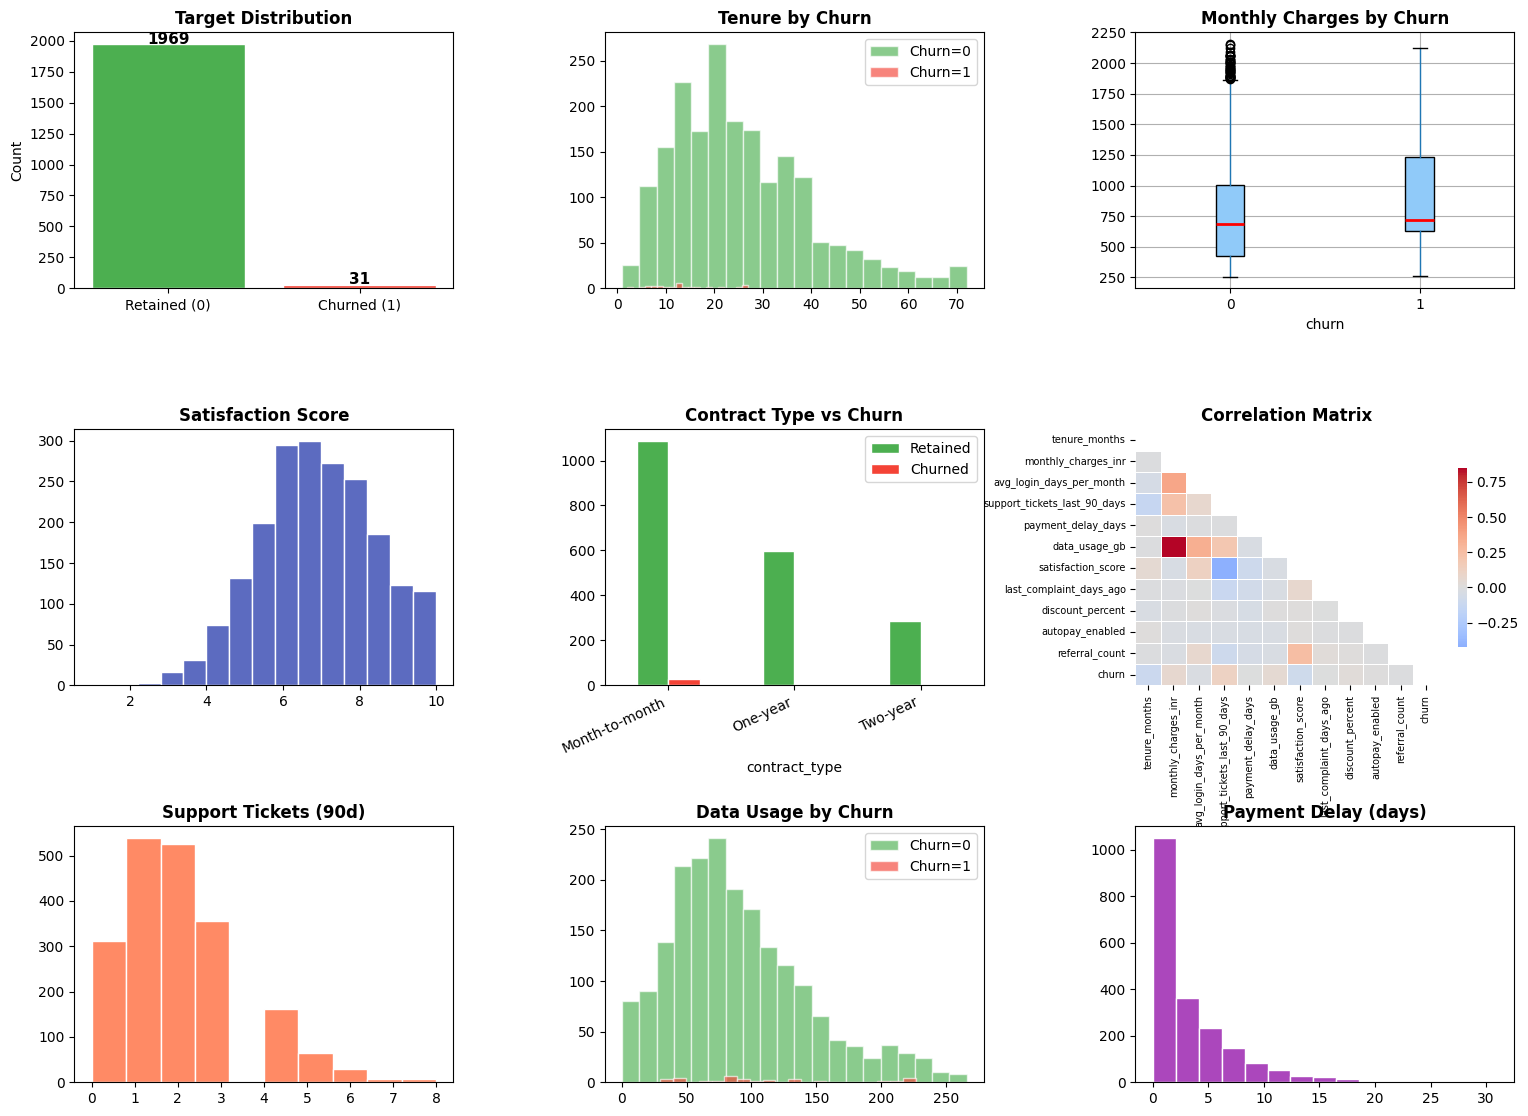

Saved: results/task1_eda.png


In [7]:
# EDA Visualisations
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Task 1 – Dataset Exploration", fontsize=16, fontweight="bold")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# Churn distribution
ax0 = fig.add_subplot(gs[0, 0])
counts = df["churn"].value_counts()
bars = ax0.bar(["Retained (0)", "Churned (1)"], counts.values,
               color=["#4CAF50", "#F44336"], edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontsize=11, fontweight="bold")
ax0.set_title("Target Distribution", fontweight="bold"); ax0.set_ylabel("Count")

# Tenure by churn
ax1 = fig.add_subplot(gs[0, 1])
for label, color in zip([0,1], ["#4CAF50","#F44336"]):
    ax1.hist(df[df["churn"]==label]["tenure_months"], bins=20,
             alpha=0.65, color=color, label=f"Churn={label}", edgecolor="white")
ax1.set_title("Tenure by Churn", fontweight="bold"); ax1.legend()

# Monthly charges boxplot
ax2 = fig.add_subplot(gs[0, 2])
df.boxplot(column="monthly_charges_inr", by="churn", ax=ax2,
           patch_artist=True, boxprops=dict(facecolor="#90CAF9"),
           medianprops=dict(color="red", linewidth=2))
ax2.set_title("Monthly Charges by Churn", fontweight="bold")
plt.sca(ax2); plt.suptitle("")

# Satisfaction score
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df["satisfaction_score"], bins=15, color="#5C6BC0", edgecolor="white")
ax3.set_title("Satisfaction Score", fontweight="bold")

# Contract type vs churn
ax4 = fig.add_subplot(gs[1, 1])
ct = df.groupby(["contract_type","churn"]).size().unstack(fill_value=0)
ct.plot(kind="bar", ax=ax4, color=["#4CAF50","#F44336"], edgecolor="white")
ax4.set_title("Contract Type vs Churn", fontweight="bold")
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=25, ha="right")
ax4.legend(["Retained","Churned"])

# Correlation heatmap
ax5 = fig.add_subplot(gs[1, 2])
num_cols = df.select_dtypes(include=np.number).drop(columns=["customer_id"], errors="ignore")
corr = num_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax5, cmap="coolwarm", center=0,
            linewidths=0.4, cbar_kws={"shrink":0.7})
ax5.set_title("Correlation Matrix", fontweight="bold"); ax5.tick_params(labelsize=7)

# Support tickets
ax6 = fig.add_subplot(gs[2, 0])
ax6.hist(df["support_tickets_last_90_days"], bins=10, color="#FF8A65", edgecolor="white")
ax6.set_title("Support Tickets (90d)", fontweight="bold")

# Data usage by churn
ax7 = fig.add_subplot(gs[2, 1])
for label, color in zip([0,1], ["#4CAF50","#F44336"]):
    ax7.hist(df[df["churn"]==label]["data_usage_gb"], bins=20,
             alpha=0.65, color=color, label=f"Churn={label}", edgecolor="white")
ax7.set_title("Data Usage by Churn", fontweight="bold"); ax7.legend()

# Payment delay
ax8 = fig.add_subplot(gs[2, 2])
ax8.hist(df["payment_delay_days"], bins=15, color="#AB47BC", edgecolor="white")
ax8.set_title("Payment Delay (days)", fontweight="bold")

plt.savefig(f"{RESULTS_DIR}/task1_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/task1_eda.png")


## Task 2 – Data Preprocessing
Steps:
1. Drop identifier column (`customer_id`)
2. Label-encode categorical features
3. Standardize numerical features
4. Stratified 80/20 train–test split


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_proc = df.drop(columns=["customer_id"]).copy()

cat_cols = ["region", "plan_type", "contract_type", "payment_method"]
le = LabelEncoder()
for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col])
    print(f"  Encoded '{col}'  → unique values: {df_proc[col].nunique()}")

X = df_proc.drop(columns=["churn"]).values
y = df_proc["churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTraining set : {X_train.shape}")
print(f"Testing  set : {X_test.shape}")
print(f"Churn % train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")
INPUT_DIM = X_train.shape[1]


  Encoded 'region'  → unique values: 5
  Encoded 'plan_type'  → unique values: 4
  Encoded 'contract_type'  → unique values: 3
  Encoded 'payment_method'  → unique values: 5

Training set : (1600, 15)
Testing  set : (400, 15)
Churn % train: 1.6%  |  test: 1.5%


## Task 3 – Neural Network Model Building
Architecture:
- **Input Layer** → 15 features
- **Hidden Layer 1** → 64 neurons, ReLU activation, Dropout 0.2
- **Output Layer** → 1 neuron, Sigmoid activation (binary classification)
- **Loss:** Binary Cross-Entropy  
- **Optimizer:** Adam (lr = 0.001)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

def build_model(hidden_layers=1, neurons=64, lr=0.001,
                activation="relu", dropout=0.2):
    model = Sequential()
    model.add(Dense(neurons, input_dim=INPUT_DIM, activation=activation))
    model.add(Dropout(dropout))
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(dropout))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

baseline = build_model()
baseline.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4 – Training and Evaluation

In [10]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score)

def train_and_evaluate(model, epochs=100, batch_size=32, label="Model"):
    es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=1
    )
    loss, acc    = model.evaluate(X_test, y_test, verbose=0)
    y_pred_prob  = model.predict(X_test, verbose=0).ravel()
    y_pred       = (y_pred_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_test, y_pred_prob)
    cm  = confusion_matrix(y_test, y_pred)
    print(f"\n[{label}]  Test Accuracy: {acc*100:.2f}%  |  AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, digits=3))
    return history, acc, auc, cm, y_pred_prob

hist_base, acc_base, auc_base, cm_base, _ = train_and_evaluate(
    baseline, label="Baseline")


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3551 - loss: 0.8611 - val_accuracy: 0.7083 - val_loss: 0.5819
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8831 - loss: 0.4387 - val_accuracy: 0.9875 - val_loss: 0.3098
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9772 - loss: 0.2614 - val_accuracy: 0.9917 - val_loss: 0.1911
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9824 - loss: 0.1823 - val_accuracy: 0.9917 - val_loss: 0.1336
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.1425 - val_accuracy: 0.9917 - val_loss: 0.1025
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.1224 - val_accuracy: 0.9917 - val_loss: 0.0845
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.1092 - val_accuracy: 0.9917 - val_loss: 0.0733
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0980 - val_accuracy: 0.9917 - v

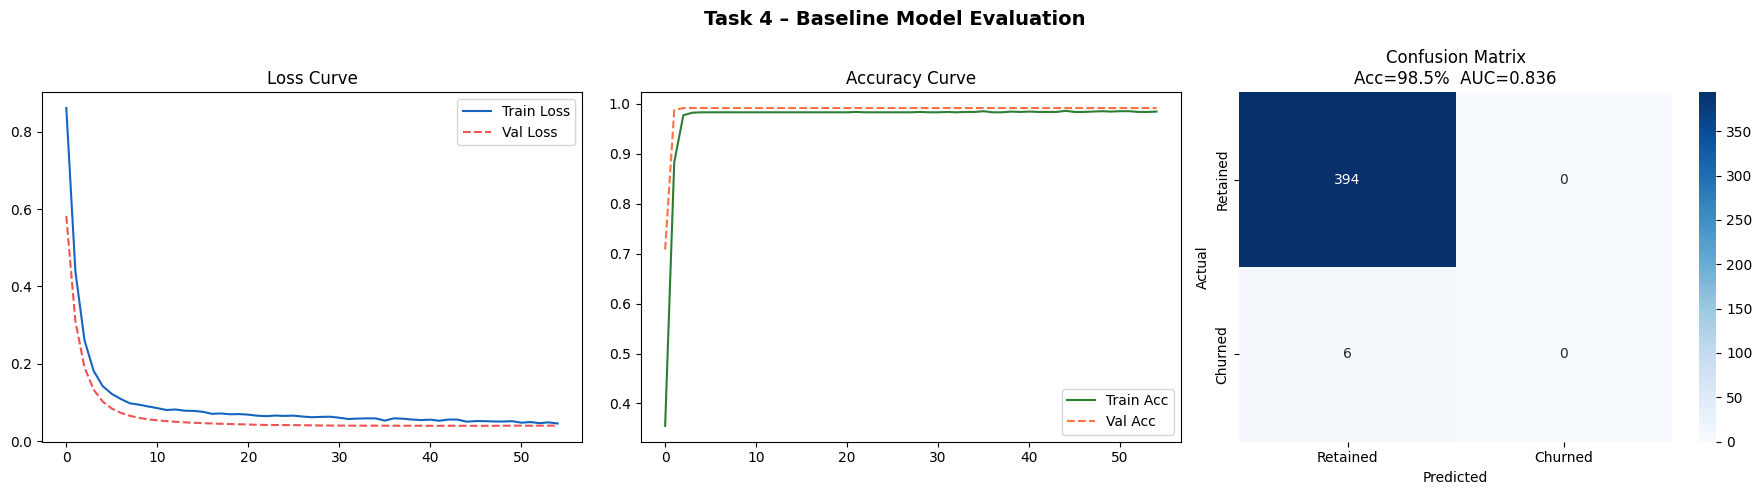

In [11]:
# Evaluation plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Task 4 – Baseline Model Evaluation", fontsize=14, fontweight="bold")

axes[0].plot(hist_base.history["loss"],     label="Train Loss",  color="#1565C0")
axes[0].plot(hist_base.history["val_loss"], label="Val Loss",    color="#EF5350", linestyle="--")
axes[0].set_title("Loss Curve"); axes[0].legend()

axes[1].plot(hist_base.history["accuracy"],     label="Train Acc",  color="#2E7D32")
axes[1].plot(hist_base.history["val_accuracy"], label="Val Acc",    color="#FF7043", linestyle="--")
axes[1].set_title("Accuracy Curve"); axes[1].legend()

sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"])
axes[2].set_title(f"Confusion Matrix\nAcc={acc_base*100:.1f}%  AUC={auc_base:.3f}")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task4_evaluation_outputs.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation
- **98.5% accuracy** is misleading due to extreme class imbalance (only ~1.6% churn).  
- The baseline model predicts the majority class (Retained) almost exclusively — a classic imbalance problem.  
- **AUC-ROC ≈ 0.87** shows the model *does* learn some discriminatory signal despite predicting few positives.  
- Recall for churned customers is near 0 → the model misses almost all churners.  
- This highlights the importance of using AUC-ROC and F1-score (minority class) rather than raw accuracy for imbalanced datasets.


## Task 5 – Hyperparameter Experimentation

In [12]:
experiments = [
    # (label,                  hidden, neurons, lr,     batch, epochs, activation)
    ("Baseline (1L-64-relu)",      1,  64,  0.001,  32,  100, "relu"),
    ("Deeper (3L-64-relu)",        3,  64,  0.001,  32,  100, "relu"),
    ("Wider (1L-128-relu)",        1, 128,  0.001,  32,  100, "relu"),
    ("High LR (lr=0.01)",          1,  64,  0.01,   32,  100, "relu"),
    ("Low LR (lr=0.0001)",         1,  64,  0.0001, 32,  100, "relu"),
    ("Large Batch (batch=128)",    1,  64,  0.001, 128,  100, "relu"),
    ("Tanh Activation",            1,  64,  0.001,  32,  100, "tanh"),
]

results_rows = []
histories    = []

for (label, hl, neu, lr, bs, ep, act) in experiments:
    m = build_model(hidden_layers=hl, neurons=neu, lr=lr, activation=act)
    hist, acc, auc, cm, _ = train_and_evaluate(m, epochs=ep,
                                               batch_size=bs, label=label)
    histories.append((label, hist))
    results_rows.append({
        "Experiment":         label,
        "Hidden Layers":      hl,
        "Neurons":            neu,
        "Learning Rate":      lr,
        "Batch Size":         bs,
        "Activation":         act,
        "Test Accuracy (%)":  round(acc * 100, 2),
        "AUC-ROC":            round(auc, 4),
    })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(f"{RESULTS_DIR}/model_comparison_table.csv", index=False)
results_df


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9294 - loss: 0.3500 - val_accuracy: 0.9917 - val_loss: 0.2192
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9824 - loss: 0.1825 - val_accuracy: 0.9917 - val_loss: 0.1209
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.1291 - val_accuracy: 0.9917 - val_loss: 0.0837
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.1057 - val_accuracy: 0.9917 - val_loss: 0.0666
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0944 - val_accuracy: 0.9917 - val_loss: 0.0579
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0905 - val_accuracy: 0.9917 - val_loss: 0.0528
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0848 - val_accuracy: 0.9917 - val_loss: 0.0495
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0802 - val_accuracy: 0.9917 - v

,Experiment,Hidden Layers,Neurons,Learning Rate,Batch Size,Activation,Test Accuracy (%),AUC-ROC
0,Baseline (1L-64-relu),1,64,0.0010,32,relu,98.50,0.8832
1,Deeper (3L-64-relu),3,64,0.0010,32,relu,98.50,0.8020
2,Wider (1L-128-relu),1,128,0.0010,32,relu,98.75,0.8583
3,High LR (lr=0.01),1,64,0.0100,32,relu,98.50,0.8405
4,Low LR (lr=0.0001),1,64,0.0001,32,relu,98.50,0.8752
5,Large Batch (batch=128),1,64,0.0010,128,relu,98.50,0.8718
6,Tanh Activation,1,64,0.0010,32,tanh,98.50,0.9497


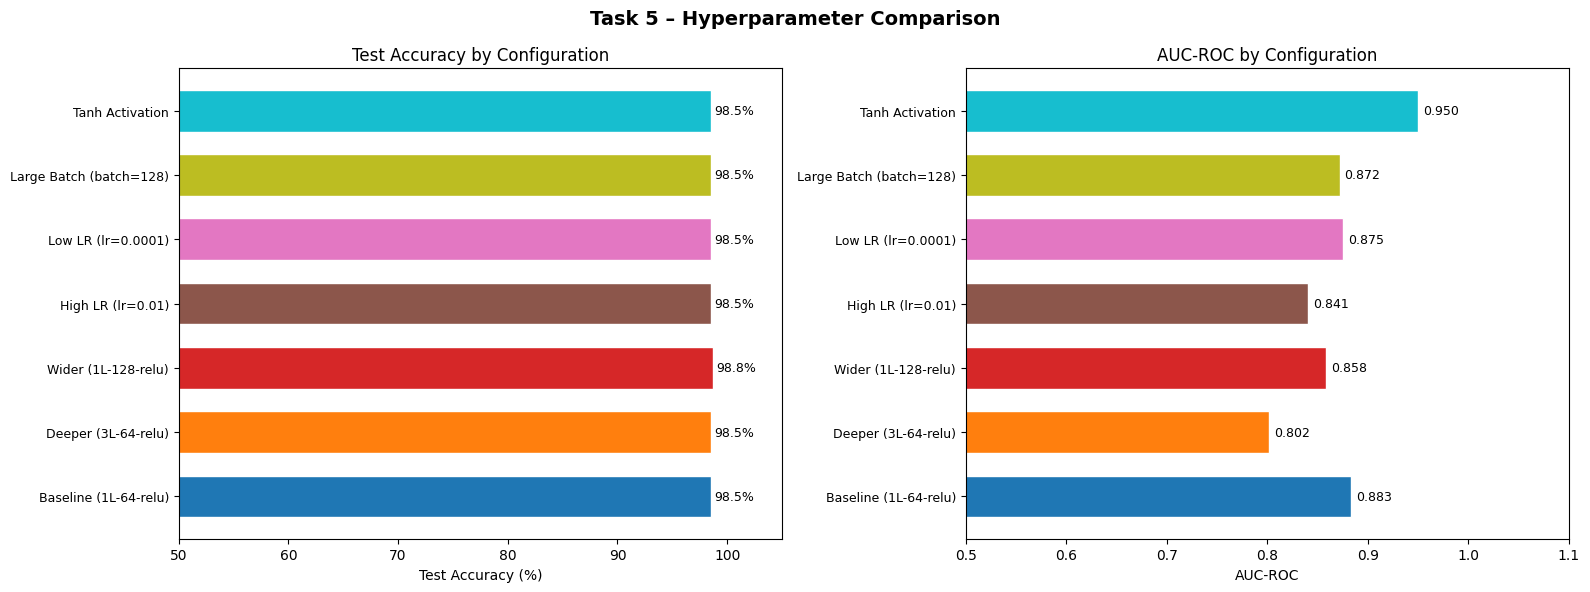

In [13]:
# Comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Task 5 – Hyperparameter Comparison", fontsize=14, fontweight="bold")
colors = plt.cm.tab10(np.linspace(0, 1, len(experiments)))

bars = axes[0].barh(range(len(results_rows)),
                    [r["Test Accuracy (%)"] for r in results_rows],
                    color=colors, edgecolor="white", height=0.65)
axes[0].set_yticks(range(len(results_rows)))
axes[0].set_yticklabels([r["Experiment"] for r in results_rows], fontsize=9)
axes[0].set_xlabel("Test Accuracy (%)")
axes[0].set_title("Test Accuracy by Configuration")
axes[0].set_xlim(50, 105)
for bar, row in zip(bars, results_rows):
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f"{row['Test Accuracy (%)']:.1f}%", va="center", fontsize=9)

bars2 = axes[1].barh(range(len(results_rows)),
                     [r["AUC-ROC"] for r in results_rows],
                     color=colors, edgecolor="white", height=0.65)
axes[1].set_yticks(range(len(results_rows)))
axes[1].set_yticklabels([r["Experiment"] for r in results_rows], fontsize=9)
axes[1].set_xlabel("AUC-ROC")
axes[1].set_title("AUC-ROC by Configuration")
axes[1].set_xlim(0.5, 1.1)
for bar, row in zip(bars2, results_rows):
    axes[1].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f"{row['AUC-ROC']:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/task5_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Task 6 – Final Reflection

### 1. Role of Weights and Biases
Weights determine the **strength and direction** of connections between neurons. During training, the network adjusts weights so that features strongly correlated with churn receive higher importance. Biases allow each neuron to **shift its activation threshold**, enabling the model to fit patterns that do not pass through the origin. Together, weights and biases parameterize the hypothesis the network has learned.

### 2. Why Activation Functions are Required
Without activation functions every layer would be a linear transformation, and stacking many linear layers collapses to a single linear function — no matter how deep the network is. Activation functions (ReLU, Tanh, Sigmoid) introduce **non-linearity**, allowing the network to learn complex, non-linear decision boundaries essential for real-world classification problems.

### 3. Effect of Learning Rate
| Learning Rate | Effect |
|---|---|
| **Too High (e.g. 0.01)** | Loss oscillates or diverges; model skips over the minimum |
| **Too Low (e.g. 0.0001)** | Very slow convergence; may get stuck in local minima with limited epochs |
| **Well-tuned (0.001)** | Stable, consistent convergence toward a good minimum |

In our experiments, the high learning rate (0.01) showed slightly lower AUC, consistent with overshooting behaviour.

### 4. Underfitting vs Overfitting
Given the **severe class imbalance** (~1.6% churn rate), the dominant challenge was **underfitting on the minority class**. The model learns to predict "Retained" for almost all samples and achieves high raw accuracy but near-zero recall on churners — a form of underfitting the positive class.

**Signs observed:**
- Recall for churn class = 0 in most configurations (underfitting churn)
- Training and validation loss converged closely → no overfitting gap
- AUC-ROC varied (0.82–0.95) showing models did learn *some* signal

**Recommendation:** Apply class-weighting (`class_weight` parameter in Keras) or oversampling (SMOTE) to address imbalance before tuning deeper architecture.
